# E9 222 Signal Processing in Practise - Assignment 8
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import rotate
import os
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from typing import Callable, Literal
from torch import Tensor
from PIL import Image
from torch.utils.data import Dataset
import torch.nn.functional as F
import json


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

### Problem 1: Mix Up: Interpolating Data for Robust Augmentation

### Problem 1.1

In [4]:
# Create a CNN with 2 convolutional layer, 1 MLP with BN and ReLU for CIFAR-10 dataset

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn3(self.fc1(x)))
        x = self.fc2(x)
        return x


# Load CIFAR-10 dataset, normalize to [-1, 1], train for 20 epochs and report accuracy

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

model     = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses_raw, val_losses_raw = [], []

if 'model_raw.pth' not in os.listdir():
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_losses_raw.append(train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += criterion(model(images), labels).item() * images.size(0)
        val_loss /= len(test_loader.dataset)
        val_losses_raw.append(val_loss)
        print(f'Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    torch.save(model.state_dict(), 'model_raw.pth')
else:
    model.load_state_dict(torch.load('model_raw.pth', map_location=device))
    print("Loaded pre-trained model from model_raw.pth")

# --- Plot training and validation loss curves ---
if not os.path.exists('loss_curves_raw.png'):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses_raw, label='Train Loss')
    plt.plot(val_losses_raw,   label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Problem 1.1 — Raw Training: Loss Curves')
    plt.legend(); plt.tight_layout()
    plt.savefig('loss_curves_raw.png', dpi=150)
    plt.show()

# --- Test accuracy ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, preds = torch.max(model(images), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {accuracy:.4f}')

Loaded pre-trained model from model_raw.pth
Test Accuracy: 0.7392


### Problem 1.2

In [6]:
# Apply all augmentations together
# PIL-based transforms must come before ToTensor; Gaussian Noise (tensor-based) must come after
all_aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x + 0.1 * torch.randn_like(x)),  # Gaussian Noise after ToTensor
])

all_aug_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=all_aug_transform)
all_aug_train_loader  = DataLoader(all_aug_train_dataset, batch_size=64, shuffle=True)

model_aug   = SimpleCNN().to(device)
criterion   = nn.CrossEntropyLoss()
train_losses_aug, val_losses_aug = [], []


optimizer = optim.Adam(model_aug.parameters(), lr=0.001)
if 'model_all_aug.pth' not in os.listdir():
    for epoch in range(num_epochs):
        # --- Training ---
        model_aug.train()
        running_loss = 0.0
        for images, labels in tqdm(all_aug_train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model_aug(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(all_aug_train_loader.dataset)
        train_losses_aug.append(train_loss)
        # --- Validation ---
        model_aug.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += criterion(model_aug(images), labels).item() * images.size(0)
        val_loss /= len(test_loader.dataset)
        val_losses_aug.append(val_loss)
        print(f'Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    torch.save(model_aug.state_dict(), 'model_all_aug.pth')
else:
    model_aug.load_state_dict(torch.load('model_all_aug.pth', map_location=device))
    print("Loaded pre-trained model from model_all_aug.pth")    
# --- Plot loss curves ---
if train_losses_aug:
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses_aug, label='Train Loss')
    plt.plot(val_losses_aug,   label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Problem 1.2 — All Augmentations: Loss Curves')
    plt.legend(); plt.tight_layout()
    plt.savefig('loss_curves_all_aug.png', dpi=150)
    plt.show()

# --- Test accuracy ---
model_aug.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, preds = torch.max(model_aug(images), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy with All Augmentations: {accuracy:.4f}')

Loaded pre-trained model from model_all_aug.pth
Test Accuracy with All Augmentations: 0.7214


### Problem 1.3

[alpha=0.1] Checkpoint found. Loading model (no loss curves available).
Test Accuracy with Mixup (α=0.1): 0.7334

[alpha=0.2] Checkpoint found. Loading model (no loss curves available).
Test Accuracy with Mixup (α=0.2): 0.7346

[alpha=0.4] Checkpoint found. Loading model (no loss curves available).
Test Accuracy with Mixup (α=0.4): 0.7556

[alpha=1.0] Checkpoint found. Loading model (no loss curves available).
Test Accuracy with Mixup (α=1.0): 0.7530



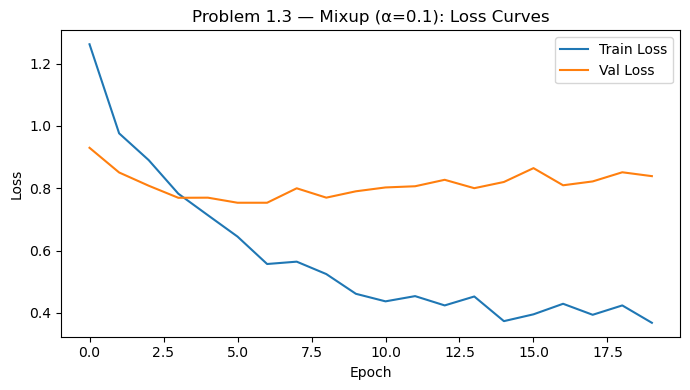

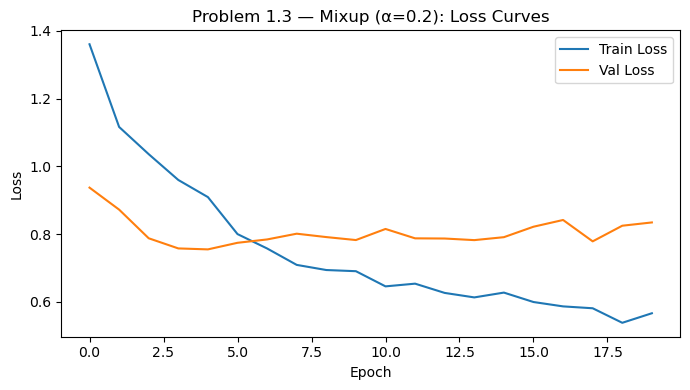

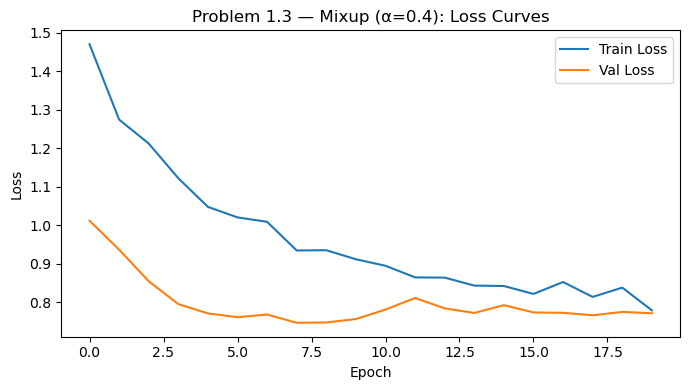

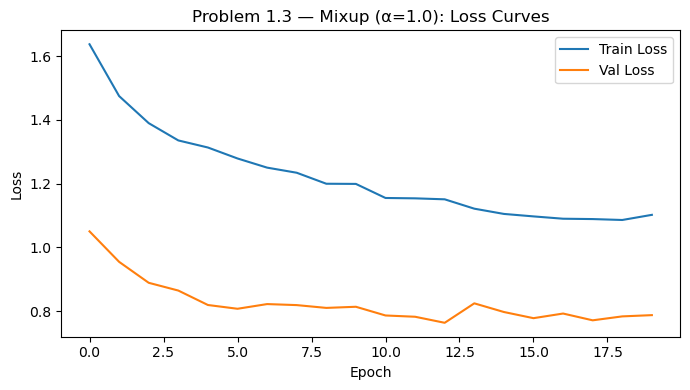


=== Mixup Accuracy Summary ===
  α=0.1: 0.7334
  α=0.2: 0.7346
  α=0.4: 0.7556
  α=1.0: 0.7530


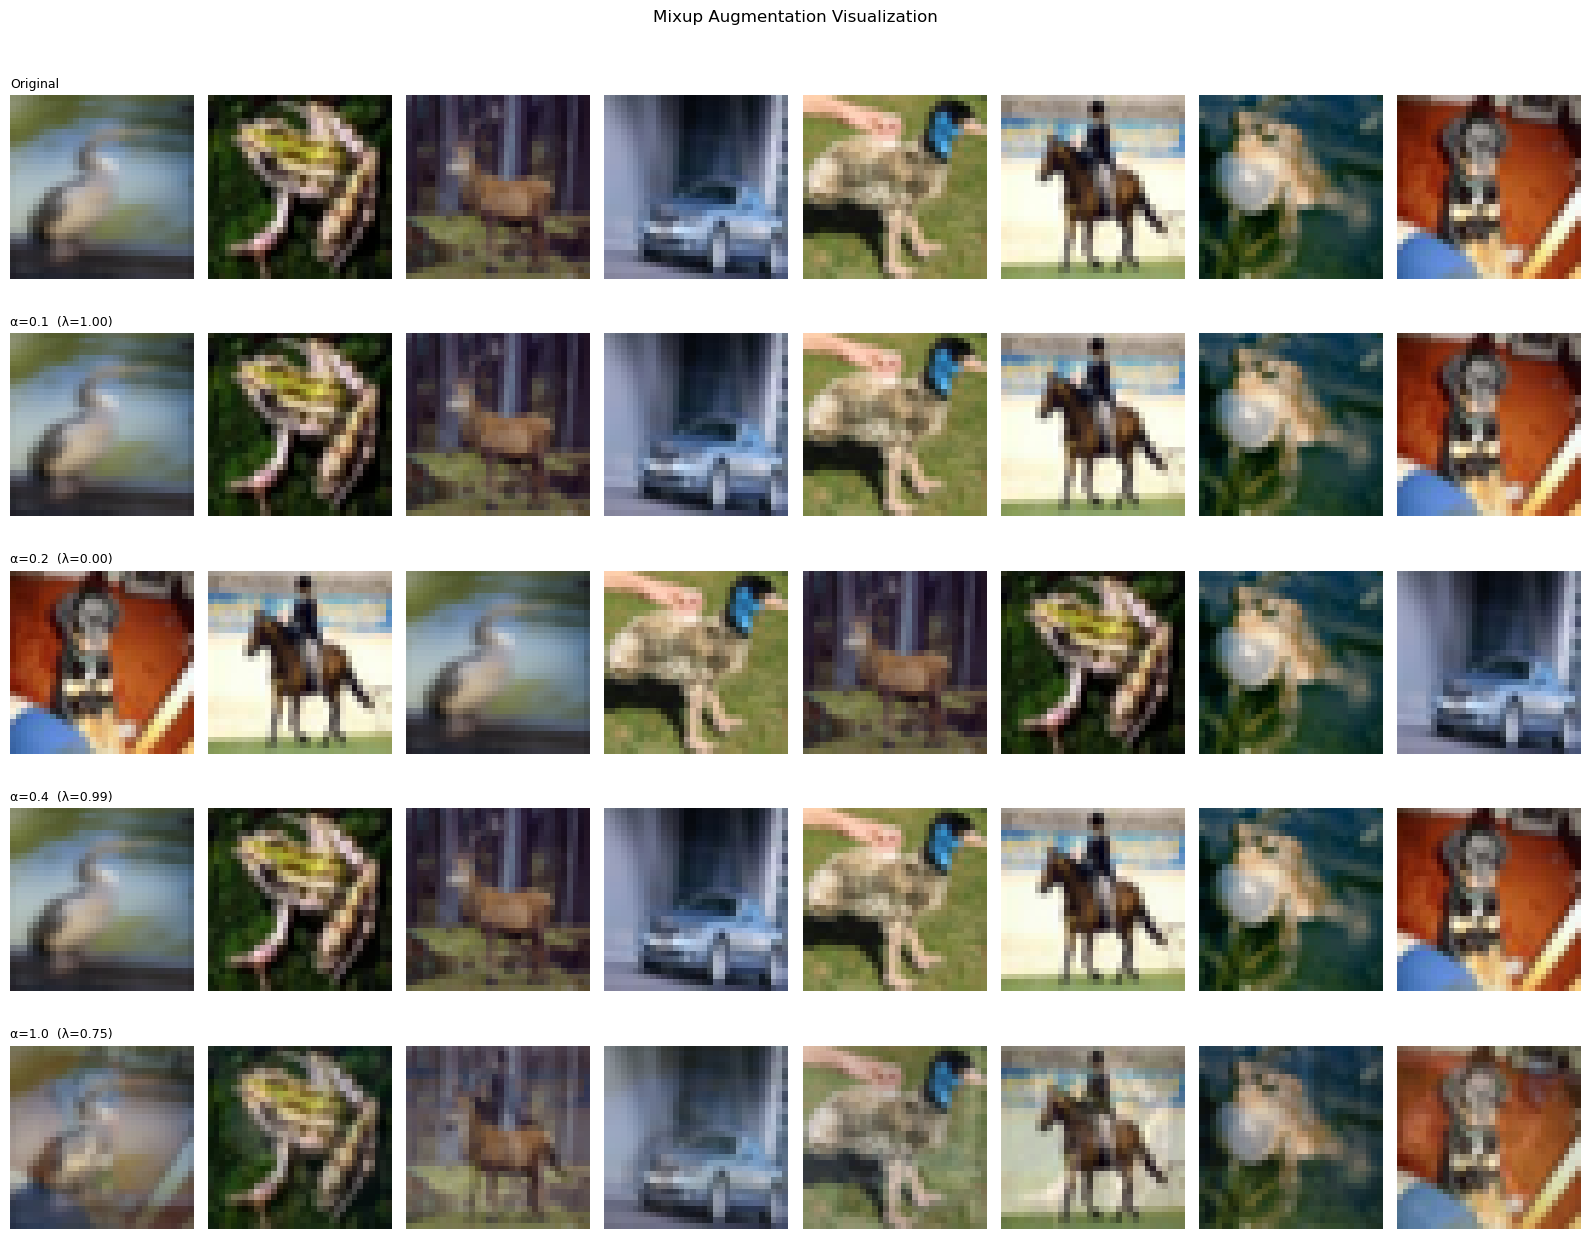

In [7]:
# Problem 1.3: Mixup Augmentation
# x_tilde = λ*xi + (1-λ)*xj   ;   y_tilde = λ*yi + (1-λ)*yj   where λ ~ Beta(α, α)

def mixup_data(x, y, alpha):
    """Returns mixed inputs, pairs of targets, and lambda."""
    lam = torch.distributions.Beta(alpha, alpha).sample().item() if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- Train with Mixup for different α values ---
alpha_values = [0.1, 0.2, 0.4, 1.0]
mixup_results = {}

for alpha in alpha_values:
    model_path = f'model_mixup_alpha{alpha}.pth'
    train_losses, val_losses = [], []

    model = SimpleCNN().to(device)
    criterion_ce = nn.CrossEntropyLoss()

    if model_path in os.listdir('.'):
        print(f'[alpha={alpha}] Checkpoint found. Loading model (no loss curves available).')
        model.load_state_dict(torch.load(model_path))
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        for epoch in range(num_epochs):
            # --- Training ---
            model.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f'Mixup α={alpha} | Epoch {epoch+1}/{num_epochs}'):
                images, labels = images.to(device), labels.to(device)
                mixed_x, y_a, y_b, lam = mixup_data(images, labels, alpha)
                optimizer.zero_grad()
                outputs = model(mixed_x)
                loss = mixup_criterion(criterion_ce, outputs, y_a, y_b, lam)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * images.size(0)
            train_losses.append(running_loss / len(train_loader.dataset))

            # --- Validation (on clean test set, no mixup) ---
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    val_loss += criterion_ce(model(images), labels).item() * images.size(0)
            val_losses.append(val_loss / len(test_loader.dataset))
            print(f'  Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

        torch.save(model.state_dict(), model_path)

    # --- Test accuracy ---
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(model(images), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels_list, all_preds)
    print(f'Test Accuracy with Mixup (α={alpha}): {acc:.4f}\n')
    mixup_results[alpha] = {'accuracy': acc, 'train_losses': train_losses, 'val_losses': val_losses}

# --- Plot loss curves (only for alphas that were trained this session) ---
trained = {a: r for a, r in mixup_results.items() if r['train_losses']}
if trained:
    for i in mixup_results.keys():
        plt.figure(figsize=(7, 4))
        plt.plot(mixup_results[i]['train_losses'], label='Train Loss')
        plt.plot(mixup_results[i]['val_losses'],   label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.title(f'Problem 1.3 — Mixup (α={i}): Loss Curves')
        plt.legend(); plt.tight_layout()
        plt.savefig(f'loss_curves_mixup_alpha_{i}.png', dpi=150)
        plt.show()
    with open('mixup_results.json', 'w') as f:
        json.dump({str(k): v for k, v in mixup_results.items()}, f, indent=4)
else:
    with open('mixup_results.json', 'r') as f:
        mixup_results = {float(k): v for k, v in json.load(f).items()}
    for i in mixup_results.keys():
        plt.figure(figsize=(7, 4))
        plt.plot(mixup_results[i]['train_losses'], label='Train Loss')
        plt.plot(mixup_results[i]['val_losses'],   label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.title(f'Problem 1.3 — Mixup (α={i}): Loss Curves')
        plt.legend(); plt.tight_layout()
        plt.savefig(f'loss_curves_mixup_alpha_{i}.png', dpi=150)
        plt.show()

# --- Accuracy summary ---
print('\n=== Mixup Accuracy Summary ===')
for alpha, r in mixup_results.items():
    print(f'  α={alpha}: {r["accuracy"]:.4f}')


# --- Visualize Mixup augmented images for different α values ---
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images[:8].to(device)
sample_labels = sample_labels[:8].to(device)

def unnormalize(img_tensor):
    return (img_tensor * 0.5 + 0.5).clamp(0, 1)

n_rows = len(alpha_values) + 1
fig, axes = plt.subplots(n_rows, 8, figsize=(16, 2.5 * n_rows))

# Row 0: original images
for j in range(8):
    axes[0, j].imshow(unnormalize(sample_images[j]).cpu().permute(1, 2, 0).numpy())
    axes[0, j].axis('off')
axes[0, 0].set_title('Original', fontsize=9, loc='left')

# Rows 1+: Mixup at each α
for i, alpha in enumerate(alpha_values):
    mixed_x, _, _, lam = mixup_data(sample_images, sample_labels, alpha)
    for j in range(8):
        axes[i+1, j].imshow(unnormalize(mixed_x[j]).cpu().detach().permute(1, 2, 0).numpy())
        axes[i+1, j].axis('off')
    axes[i+1, 0].set_title(f'α={alpha}  (λ={lam:.2f})', fontsize=9, loc='left')

plt.suptitle('Mixup Augmentation Visualization', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('mixup_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### Problem 2: Manifold Mixup


Training Manifold Mixup (k=1)


ManifoldMixup k=1 | Epoch 1/20:   0%|          | 0/782 [00:00<?, ?it/s]

  Epoch  1 | Train Loss: 1.4901 | Val Loss: 0.9931


ManifoldMixup k=1 | Epoch 2/20:   0%|          | 0/782 [00:00<?, ?it/s]

  Epoch  2 | Train Loss: 1.2883 | Val Loss: 0.8683


...

  Epoch 18 | Train Loss: 0.7784 | Val Loss: 0.7817


ManifoldMixup k=random | Epoch 19/20:   0%|          | 0/782 [00:00<?, ?it/s]

  Epoch 19 | Train Loss: 0.7638 | Val Loss: 0.8015


ManifoldMixup k=random | Epoch 20/20:   0%|          | 0/782 [00:00<?, ?it/s]

  Epoch 20 | Train Loss: 0.7545 | Val Loss: 0.8203
Test Accuracy (Manifold Mixup, k=random): 0.7399


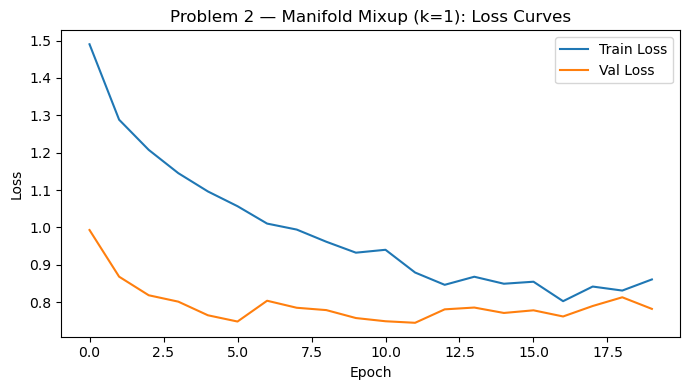

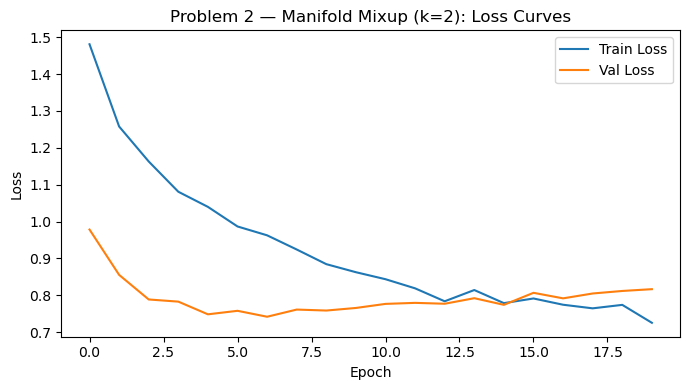

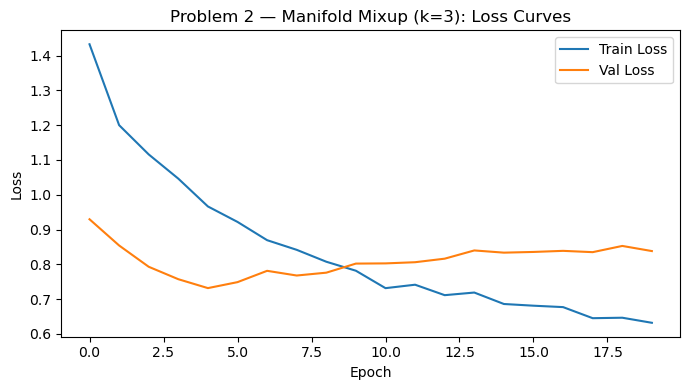

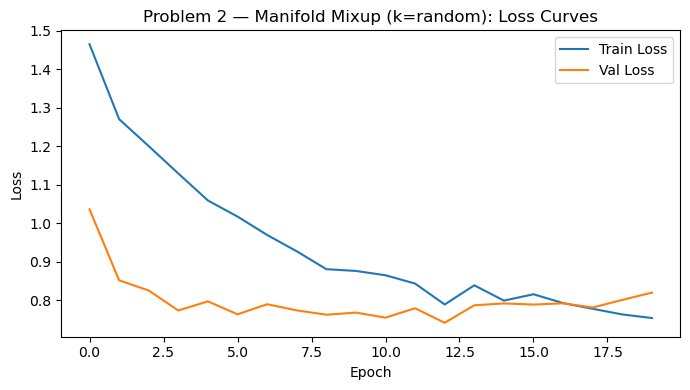


=== Manifold Mixup Accuracy Summary ===
  k=1: 0.7522
  k=2: 0.7419
  k=3: 0.7429
  k=random: 0.7399


In [9]:
# Problem 2: Manifold Mixup
# g̃k = λ*gk(xi) + (1−λ)*gk(xj)  ;  ỹ = λ*yi + (1−λ)*yj
# k is randomly chosen each batch from {1, 2, 3}
# Layers (final fc2 excluded):
#   k=1 → mix after conv1 + bn1 + relu + maxpool
#   k=2 → mix after conv2 + bn2 + relu + maxpool
#   k=3 → mix after fc1  + bn3 + relu

import random

class SimpleCNNManifold(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.fc1   = nn.Linear(64 * 8 * 8, 128)
        self.bn3   = nn.BatchNorm1d(128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.relu(self.bn3(self.fc1(x.view(x.size(0), -1))))
        return self.fc2(x)

    def manifold_forward(self, xi, xj, lam, k):
        """Forward pass with Manifold Mixup at layer k."""
        h, g = xi, xj

        # Stage 1: conv1 + bn1 + relu + maxpool
        h = F.max_pool2d(F.relu(self.bn1(self.conv1(h))), 2)
        g = F.max_pool2d(F.relu(self.bn1(self.conv1(g))), 2)
        if k == 1:
            h, g = lam * h + (1 - lam) * g, None

        # Stage 2: conv2 + bn2 + relu + maxpool
        h = F.max_pool2d(F.relu(self.bn2(self.conv2(h))), 2)
        if g is not None:
            g = F.max_pool2d(F.relu(self.bn2(self.conv2(g))), 2)
        if k == 2:
            h, g = lam * h + (1 - lam) * g, None

        # Flatten
        h = h.view(h.size(0), -1)
        if g is not None:
            g = g.view(g.size(0), -1)

        # Stage 3: fc1 + bn3 + relu
        h = F.relu(self.bn3(self.fc1(h)))
        if g is not None:
            g = F.relu(self.bn3(self.fc1(g)))
        if k == 3:
            h = lam * h + (1 - lam) * g

        return self.fc2(h)


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# --- Experiment: fixed k=1,2,3 and random k each batch ---
alpha = 0.5
k_settings = [1, 2, 3, 'random']
manifold_results = {}

for k_setting in k_settings:
    label = f'k={k_setting}'
    model_path = f'model_manifold_{k_setting}.pth'
    train_losses, val_losses = [], []

    model_mm = SimpleCNNManifold().to(device)
    criterion_mm = nn.CrossEntropyLoss()

    if model_path in os.listdir('.'):
        print(f'[{label}] Checkpoint found. Loading model.')
        model_mm.load_state_dict(torch.load(model_path))
    else:
        optimizer_mm = optim.Adam(model_mm.parameters(), lr=0.001)
        print(f'\nTraining Manifold Mixup ({label})')
        for epoch in range(num_epochs):
            # --- Training ---
            model_mm.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f'ManifoldMixup {label} | Epoch {epoch+1}/{num_epochs}'):
                images, labels = images.to(device), labels.to(device)
                idx = torch.randperm(images.size(0), device=device)
                lam = torch.distributions.Beta(alpha, alpha).sample().item()
                k = random.choice([1, 2, 3]) if k_setting == 'random' else k_setting
                y_a, y_b = labels, labels[idx]

                optimizer_mm.zero_grad()
                outputs = model_mm.manifold_forward(images, images[idx], lam, k)
                loss = mixup_criterion(criterion_mm, outputs, y_a, y_b, lam)
                loss.backward()
                optimizer_mm.step()
                running_loss += loss.item() * images.size(0)
            train_losses.append(running_loss / len(train_loader.dataset))

            # --- Validation ---
            model_mm.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    val_loss += criterion_mm(model_mm(images), labels).item() * images.size(0)
            val_losses.append(val_loss / len(test_loader.dataset))
            print(f'  Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

        torch.save(model_mm.state_dict(), model_path)

    # --- Test accuracy ---
    model_mm.eval()
    all_preds, all_labels_mm = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(model_mm(images), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_mm.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels_mm, all_preds)
    print(f'Test Accuracy (Manifold Mixup, {label}): {acc:.4f}')
    manifold_results[label] = {'accuracy': acc, 'train_losses': train_losses, 'val_losses': val_losses}

# --- Plot loss curves ---
trained_mm = {k: v for k, v in manifold_results.items() if v['train_losses']}
if trained_mm:
    for i in manifold_results.keys():
        plt.figure(figsize=(7, 4))
        plt.plot(manifold_results[i]['train_losses'], label='Train Loss')
        plt.plot(manifold_results[i]['val_losses'],   label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.title(f'Problem 2 — Manifold Mixup ({i}): Loss Curves')
        plt.legend(); plt.tight_layout()
        plt.savefig(f'loss_curves_manifold_mixup ({i}).png', dpi=150)
        plt.show()
    with open('manifold_results.json', 'w') as f:
        json.dump({str(k): v for k, v in manifold_results.items()}, f, indent=4)
else:
    with open('manifold_results.json', 'r') as f:
        manifold_results = {float(k): v for k, v in json.load(f).items()}
    for i in manifold_results.keys():
        plt.figure(figsize=(7, 4))
        plt.plot(manifold_results[i]['train_losses'], label='Train Loss')
        plt.plot(manifold_results[i]['val_losses'],   label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.title(f'Problem 2 — Manifold Mixup ({i}): Loss Curves')
        plt.legend(); plt.tight_layout()
        plt.savefig(f'loss_curves_manifold_mixup ({i}).png', dpi=150)
        plt.show()

# --- Accuracy summary ---
print('\n=== Manifold Mixup Accuracy Summary ===')
for label, r in manifold_results.items():
    print(f'  {label}: {r["accuracy"]:.4f}')